In [1]:
import scipy.signal as signal
import numpy as np
import matplotlib.pyplot as plt 

%matplotlib widget


# Filtro IIR

In [2]:
# Pasa banda
fs = 1000               # Freq de muestreo
N = fs                  # Cant Muestras
f0 = [100, 150]         # Freq de paso
f_cutoff = [10, 240]    # Freq de stop

Att_pass_db = 1         # ATT en banda de paso. Tambien se conoce como ripple.
att_stop_db = 40        # ATT en banda de stop

sos = signal.iirdesign(wp=f0, ws=f_cutoff, 
					   gpass=Att_pass_db, gstop=att_stop_db, fs=fs, 
					   analog=False, ftype='butter', output='sos')
# output = 'sos'    --> Sections Order 2. Usa multiples secciones de orden 2 o menor.

print('coeficientes del filtro SOS')
print(sos)

coeficientes del filtro SOS
[[ 7.59375040e-04  1.51875008e-03  7.59375040e-04  1.00000000e+00
  -1.11414147e+00  6.87308801e-01]
 [ 1.00000000e+00  2.00000000e+00  1.00000000e+00  1.00000000e+00
  -1.31756720e+00  7.25183667e-01]
 [ 1.00000000e+00 -2.00000000e+00  1.00000000e+00  1.00000000e+00
  -1.05988634e+00  8.48909817e-01]
 [ 1.00000000e+00 -2.00000000e+00  1.00000000e+00  1.00000000e+00
  -1.54400573e+00  8.91099885e-01]]


Analisis de la respuesta

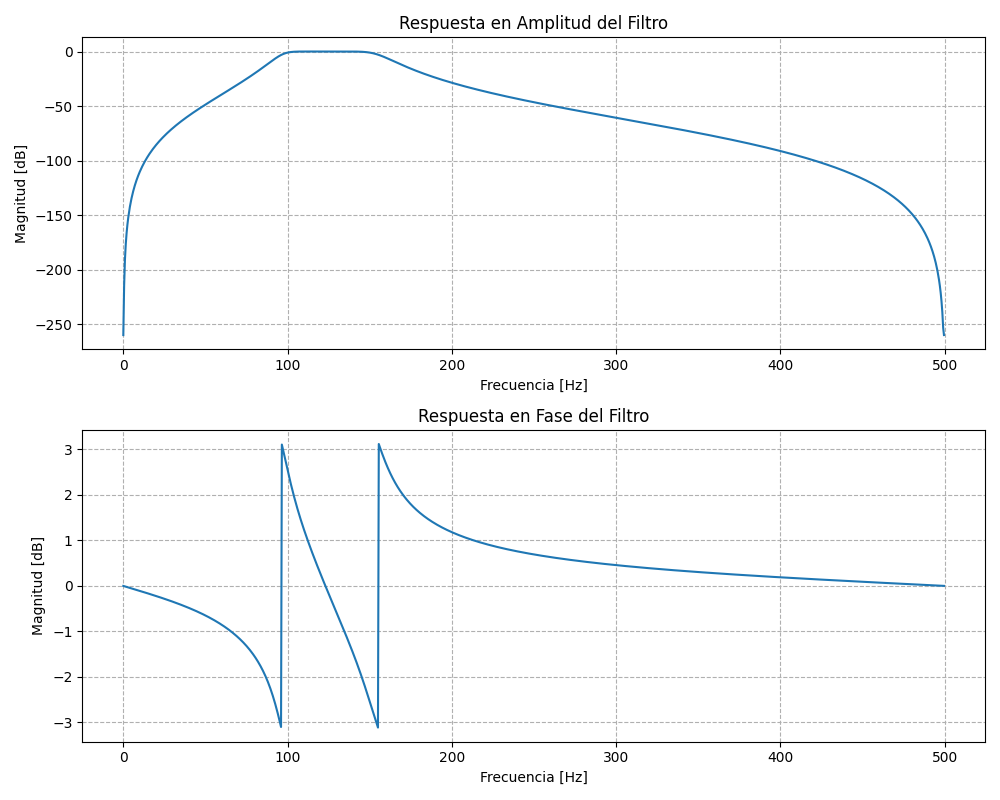

In [3]:
w,tt = signal.freqz_sos(sos, worN=N,  fs=fs)
# WorN: Omega o N. Le pasás el valor de mayor detalle para realizar el analisis del filtro.

plt.figure(figsize=(10,8))
plt.subplot(2,1,1)
plt.plot(w, 20*np.log10(np.maximum(abs(tt), 1e-13)))
plt.title('Respuesta en Amplitud del Filtro')
plt.ylabel('Magnitud [dB]')
plt.xlabel('Frecuencia [Hz]')
plt.grid(True, which='both', ls='--')
#plt.ylim([-60, 5])

fase = np.angle(tt) #np.unwrap(np.angle(tt))
plt.subplot(2,1,2)
plt.plot(w, fase)
plt.title('Respuesta en Fase del Filtro')
plt.ylabel('Magnitud [dB]')
plt.xlabel('Frecuencia [Hz]')
plt.grid(True, which='both', ls='--')
#plt.ylim([-90, 90])
plt.tight_layout()
plt.show()




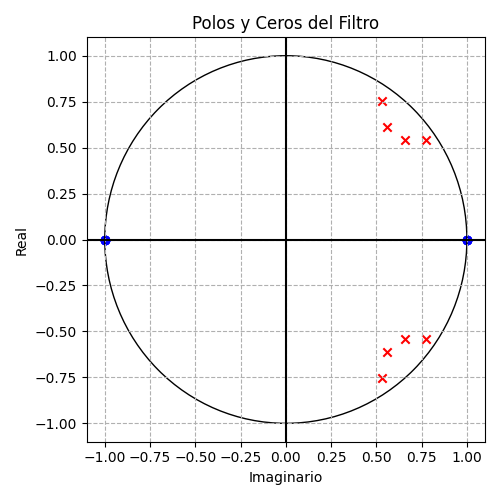

In [4]:
z, p, k = signal.sos2zpk(sos)

fig, ax = plt.subplots(figsize=(5,5))
plt.scatter(np.real(z), np.imag(z), color='b', marker='o')
plt.scatter(np.real(p), np.imag(p), color='r', marker='x')
circle = plt.Circle((0,0), 1, fill=False)
ax.add_patch(circle)
ax.set_xlim((-1.1, 1.1))
ax.set_ylim((-1.1, 1.1))

ax.axhline(0, color='black')
ax.axvline(0, color='black')
plt.grid(True, which='both', ls='--')
plt.title('Polos y Ceros del Filtro')
plt.ylabel('Real')
plt.xlabel('Imaginario')
plt.tight_layout()
plt.show()

Prueba 2

Diseño con otra plantilla

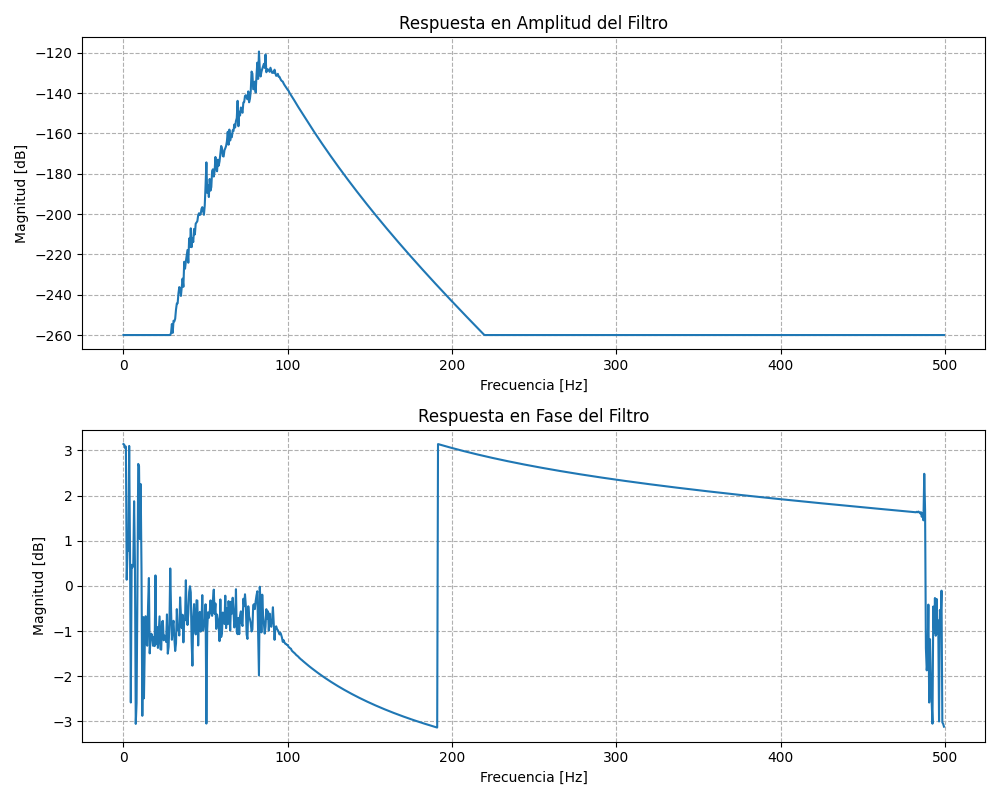

In [5]:
# Pasa banda
fs = 1000               # Freq de muestreo
N = fs                  # Cant Muestras
f0 = [1, 35]         # Freq de paso
f_cutoff = [0.1, 50]    # Freq de stop

Att_pass_db = 1         # ATT en banda de paso. Tambien se conoce como ripple.
att_stop_db = 40        # ATT en banda de stop

b, a = signal.iirdesign(wp=f0, ws=f_cutoff, 
                       gpass=Att_pass_db, gstop=att_stop_db, fs=fs, 
                       analog=False, ftype='butter', output='ba')

w,tt = signal.freqz(b, a, worN=N,  fs=fs)

plt.figure(figsize=(10,8))
plt.subplot(2,1,1)
plt.plot(w, 20*np.log10(np.maximum(abs(tt), 1e-13)))
plt.title('Respuesta en Amplitud del Filtro')
plt.ylabel('Magnitud [dB]')
plt.xlabel('Frecuencia [Hz]')
plt.grid(True, which='both', ls='--')
#plt.ylim([-60, 5])

fase = np.angle(tt) #np.unwrap(np.angle(tt))
plt.subplot(2,1,2)
plt.plot(w, fase)
plt.title('Respuesta en Fase del Filtro')
plt.ylabel('Magnitud [dB]')
plt.xlabel('Frecuencia [Hz]')
plt.grid(True, which='both', ls='--')
#plt.ylim([-90, 90])
plt.tight_layout()
plt.show()


e:\Agustin\Escritorio\Procesamiento-Digital-de-Se-ales---2026\.venv\Lib\site-packages\scipy\signal\_filter_design.py:1233: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  b, a = normalize(b, a)


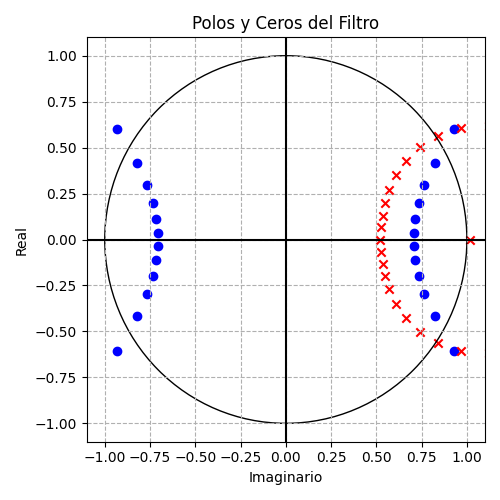

In [6]:
z, p, k = signal.tf2zpk(b, a)

fig, ax = plt.subplots(figsize=(5,5))
plt.scatter(np.real(z), np.imag(z), color='b', marker='o')
plt.scatter(np.real(p), np.imag(p), color='r', marker='x')
circle = plt.Circle((0,0), 1, fill=False)
ax.add_patch(circle)
ax.set_xlim((-1.1, 1.1))
ax.set_ylim((-1.1, 1.1))

ax.axhline(0, color='black')
ax.axvline(0, color='black')
plt.grid(True, which='both', ls='--')
plt.title('Polos y Ceros del Filtro')
plt.ylabel('Real')
plt.xlabel('Imaginario')
plt.tight_layout()
plt.show()

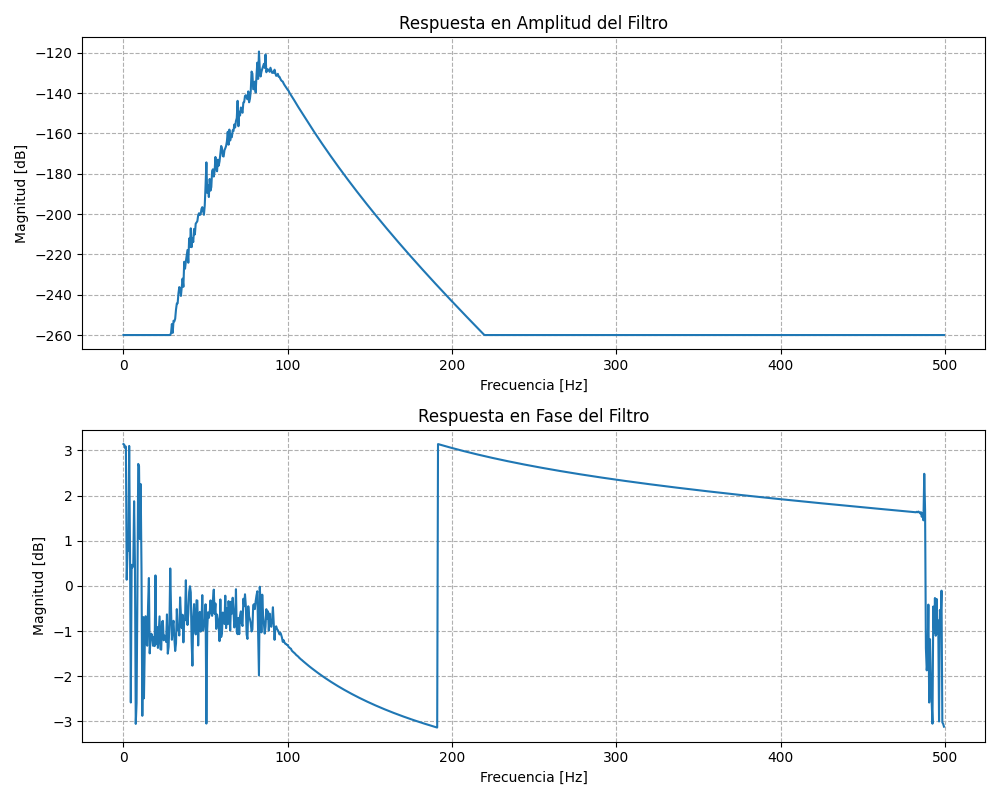

In [7]:
# Pasa banda
fs = 1000               # Freq de muestreo
N = fs                  # Cant Muestras
f0 = [1, 35]         # Freq de paso
f_cutoff = [0.1, 50]    # Freq de stop

Att_pass_db = 1         # ATT en banda de paso. Tambien se conoce como ripple.
att_stop_db = 40        # ATT en banda de stop

b, a = signal.iirdesign(wp=f0, ws=f_cutoff, 
					   gpass=Att_pass_db, gstop=att_stop_db, fs=fs, 
					   analog=False, ftype='butter', output='ba')

w,tt = signal.freqz(b, a, worN=N,  fs=fs)

plt.figure(figsize=(10,8))
plt.subplot(2,1,1)
plt.plot(w, 20*np.log10(np.maximum(abs(tt), 1e-13)))
plt.title('Respuesta en Amplitud del Filtro')
plt.ylabel('Magnitud [dB]')
plt.xlabel('Frecuencia [Hz]')
plt.grid(True, which='both', ls='--')
#plt.ylim([-60, 5])

fase = np.angle(tt) #np.unwrap(np.angle(tt))
plt.subplot(2,1,2)
plt.plot(w, fase)
plt.title('Respuesta en Fase del Filtro')
plt.ylabel('Magnitud [dB]')
plt.xlabel('Frecuencia [Hz]')
plt.grid(True, which='both', ls='--')
#plt.ylim([-90, 90])
plt.tight_layout()
plt.show()


# Filtro FIR